In [7]:
import pandas as pd
import numpy as np

# **Brakujące wartości**

**Brakujące wartości** to rekordy, które są nieobecne w zestawie danych.

**Przyczyny występowania**:
* Błąd człowieka podczas wprowadzania danych​

* Ochrona prywatności (dane wrażliwe)
* Brak odpowiedzi w ankietach

Problemy techniczne przy zbieraniu danych

Jest to jeden z **najczęściej występujących problemów** w analizie danych i kluczowy etap wstępnego przetwarzania (data preprocessing).

In [8]:
# Definicja DataFrame
df_student = pd.DataFrame({
    'imie': ['Anna', 'Piotr', 'Maria', 'Jan', 'Katarzyna', 'Tomasz', 'Magdalena', 'Paweł', 'Ewa', 'Michał'],
    'wiek': [20, 22, 21, np.nan, 23, 20, 22, np.nan, 21, 23],
    'ocena_matematyka': [4.5, np.nan, 5.0, 4.0, 3.5, 4.5, 5.0, 3.5, np.nan, 4.0],
    'ocena_fizyka': [5.0, 4.5, np.nan, 4.0, 4.5, np.nan, 5.0, 4.0, 4.5, np.nan],
    'ocena_informatyka': [4.0, 3.5, 4.5, np.nan, 5.0, 3.5, 4.5, 4.0, np.nan, 4.5],
    'miasto': ['Warszawa', 'Kraków', 'Wrocław', 'Poznań', 'Gdańsk', np.nan, 'Warszawa', 'Kraków', 'Wrocław', 'Poznań']
})

In [9]:
# 1. Sprawdzenie czy są brakujące wartości
print("1. Sprawdzenie brakujących wartości (True = brak):")
print(df_student.isnull())
# lub: df.isna()
print("\n" + "="*60 + "\n")

1. Sprawdzenie brakujących wartości (True = brak):
    imie   wiek  ocena_matematyka  ocena_fizyka  ocena_informatyka  miasto
0  False  False             False         False              False   False
1  False  False              True         False              False   False
2  False  False             False          True              False   False
3  False   True             False         False               True   False
4  False  False             False         False              False   False
5  False  False             False          True              False    True
6  False  False             False         False              False   False
7  False   True             False         False              False   False
8  False  False              True         False               True   False
9  False  False             False          True              False   False




In [10]:
# 2. Liczba brakujących wartości w każdej kolumnie
print("2. Liczba brakujących wartości w każdej kolumnie:")
print(df_student.isna().sum())
print("\n" + "="*60 + "\n")

2. Liczba brakujących wartości w każdej kolumnie:
imie                 0
wiek                 2
ocena_matematyka     2
ocena_fizyka         3
ocena_informatyka    2
miasto               1
dtype: int64




In [11]:
# 4. Całkowita liczba brakujących wartości
print("4. Całkowita liczba brakujących wartości w całym DataFrame:")
print(df_student.isnull().sum().sum())

4. Całkowita liczba brakujących wartości w całym DataFrame:
10


## **Rozwiązanie kwestii brakujących danych**

* **Usuwanie rekordów** zawierających brakujące wartości.
* **Ręczne uzupełnianie** brakujących wartości.
* Uzupełnianie **brakujących wartości wskaźnikami** tendencji centralnej, np.: średnią, medianą czy dominantą.
  * **Średniej** używamy w przypadku cech numerycznych,
  * **mediany** w cechach porządkowych,
  * **dominantę** (czyli najczęściej powtarzającą się wartość) umieszczamy w cechach kategorialnych.

Uzupełnianie **najbardziej prawdopodobną wartością** przy użyciu modeli uczenia maszynowego, takich jak regresja, drzewa decyzyjne czy algorytm KNN.

## **Czym jest NaN i dlaczego jest wyjątkowy?**

**NaN** (Not a Number) – specjalna wartość reprezentująca brakujące dane.

Dane mogą zawierać różne oznaczenia braków:
* Tekstowe: "NA", "N/A", "brak", "?", "-"

* Numeryczne: 0, -999, -1​

* Inne: puste stringi ""

In [12]:
df = pd.DataFrame({
    'A': [1, np.nan, 3],# ✓ NaN - brakująca wartość ​
    'B': [4, None, 6],  # ✓ None - też brakująca ​
    'C': [7, 0, 9],     # ✗ 0 - NIE jest brakująca! ​
    'D': ['x', '', 'z'] # ✗ '' - NIE jest brakująca! ​
})

In [13]:
df.isnull().sum()

,0
A,1
B,1
C,0
D,0


## **Usuwanie brakujących wartości**

Usuń wiersze z DOWOLNĄ brakującą wartością (domyślnie) ​

```
df.dropna()
df.dropna(how='any')
```

Usuń wiersze tylko gdy WSZYSTKIE wartości są brakujące df.dropna(how='all')
```
df.dropna(how="all")
```

Usuń kolumny z brakującymi wartościami
```
df.dropna(axis=1)
```

## **Uzupełnienie średnią lub modą​**

W pandas *dataFrame* możemy uzupełnić brakujące wartości za pomocą funkcji `fillna()`.
* Przyjmuje ona jedną wartość, która będzie wstawiana w pustych pozycjach lub zamiast wartości NaN.

Uzupełnia wszystkie brakujące wartości w kolumnie age średnią obliczoną z tejże kolumny

```data['age'] = data.age.fillna(data.age.mean())​```

Uzupełnia wszystkie brakujące wartości w kolumnie income medianą obliczoną z tejże kolumny

```data['income']=data.income.fillna(data.income.median())```

Zastępuje wszystkie brakujące wartości w kolumnie gender (kolumna kategorii) dominantą wyliczoną z tejże kolumny​

```data['gender']=data['gender'].fillna(data['gender'].mode()[0])​```

In [14]:
df_student["wiek"] = df_student.wiek.fillna(df_student.wiek.mean())
df_student

,imie,wiek,ocena_matematyka,ocena_fizyka,ocena_informatyka,miasto
0,Anna,20.0,4.5,5.0,4.0,Warszawa
1,Piotr,22.0,NaN,4.5,3.5,Kraków
2,Maria,21.0,5.0,NaN,4.5,Wrocław
3,Jan,21.5,4.0,4.0,NaN,Poznań
4,Katarzyna,23.0,3.5,4.5,5.0,Gdańsk
5,Tomasz,20.0,4.5,NaN,3.5,NaN
6,Magdalena,22.0,5.0,5.0,4.5,Warszawa
7,Paweł,21.5,3.5,4.0,4.0,Kraków
8,Ewa,21.0,NaN,4.5,NaN,Wrocław
9,Michał,23.0,4.0,NaN,4.5,Poznań


In [15]:
df_student["ocena_matematyka"] = df_student["ocena_matematyka"] .fillna(df_student["ocena_matematyka"] .mean())
df_student

,imie,wiek,ocena_matematyka,ocena_fizyka,ocena_informatyka,miasto
0,Anna,20.0,4.50,5.0,4.0,Warszawa
1,Piotr,22.0,4.25,4.5,3.5,Kraków
2,Maria,21.0,5.00,NaN,4.5,Wrocław
3,Jan,21.5,4.00,4.0,NaN,Poznań
4,Katarzyna,23.0,3.50,4.5,5.0,Gdańsk
5,Tomasz,20.0,4.50,NaN,3.5,NaN
6,Magdalena,22.0,5.00,5.0,4.5,Warszawa
7,Paweł,21.5,3.50,4.0,4.0,Kraków
8,Ewa,21.0,4.25,4.5,NaN,Wrocław
9,Michał,23.0,4.00,NaN,4.5,Poznań


In [16]:
df_student["miasto"] = df_student["miasto"].fillna(df_student["miasto"] .mode()[0])
df_student

,imie,wiek,ocena_matematyka,ocena_fizyka,ocena_informatyka,miasto
0,Anna,20.0,4.50,5.0,4.0,Warszawa
1,Piotr,22.0,4.25,4.5,3.5,Kraków
2,Maria,21.0,5.00,NaN,4.5,Wrocław
3,Jan,21.5,4.00,4.0,NaN,Poznań
4,Katarzyna,23.0,3.50,4.5,5.0,Gdańsk
5,Tomasz,20.0,4.50,NaN,3.5,Kraków
6,Magdalena,22.0,5.00,5.0,4.5,Warszawa
7,Paweł,21.5,3.50,4.0,4.0,Kraków
8,Ewa,21.0,4.25,4.5,NaN,Wrocław
9,Michał,23.0,4.00,NaN,4.5,Poznań


## **Obsługa brakujących danych jako stringi**

**Problem**
* Dane często zawierają braki zapisane jako tekst: **"NA", "N/A", "brak", "?", "-", "brak danych"**

* Pandas **nie rozpoznaje** ich automatycznie jako brakujące wartości!

### **Rozwiązanie 1: Wczytywanie z pliku CSV**

```
import pandas as pd

# Definiujemy listę wartości oznaczających brak
braki = ['NA', 'N/A', 'brak', 'brak danych', '?', '-', '']

# Wczytujemy plik z parametrem na_values
df = pd.read_csv('dane.csv', na_values=braki)

```

### **Rozwiązanie 2: Zamiana po wczytaniu**

```
# Zamieniamy wybrane stringi na NaN
df.replace(['NA', 'N/A', 'brak', 'brak danych', '?', '-'], np.nan, inplace=True)

# LUB dla konkretnej kolumny
df['kolumna'] = df['kolumna'].replace('brak', np.nan)
```

# **Zadanie**:

**Dane**: Plik *nieruchomosci.csv* - 45 ofert sprzedaży mieszkań

**Polecenie**

* Wczytaj dane i przeanalizuj problem brakujących wartości

* Zdecyduj, jak poradzić sobie z brakami w poszczególnych kolumnach

* Uzasadnij swoje wybory i zaimplementuj rozwiązanie

**Do przemyślenia**

* Jakie typy zmiennych masz w danych?
* Czy wszystkie braki powinny być obsłużone tak samo?
* Jakie konsekwencje niesie każda metoda?
* Jak to wpływa na eksploracyjną analizę danych?


Statystyki opisowe:
              id  powierzchnia  liczba_pokoi   rok_budowy      pietro  liczba_pieter       cena_m2    cena_total
count  45.000000     45.000000     45.000000    45.000000   45.000000      45.000000     45.000000  4.500000e+01
mean   23.000000     59.977778      2.688889  2010.477778  -41.544444       6.911111   9746.666667  6.590822e+05
std    13.133926     20.311762      0.924962     7.192922  208.832736       3.043788   2735.914348  1.502189e+05
min     1.000000      0.000000      1.000000  1995.000000 -999.000000       2.000000   -999.000000  4.250000e+05
25%    12.000000     54.000000      2.000000  2006.000000    1.000000       4.000000   8900.000000  5.750000e+05
50%    23.000000     62.000000      3.000000  2011.500000    2.500000       7.000000   9700.000000  6.480000e+05
75%    34.000000     70.000000      3.000000  2016.000000    4.000000       9.000000  11000.000000  7.056000e+05
max    45.000000     95.000000      5.000000  2022.000000    8.000000      1

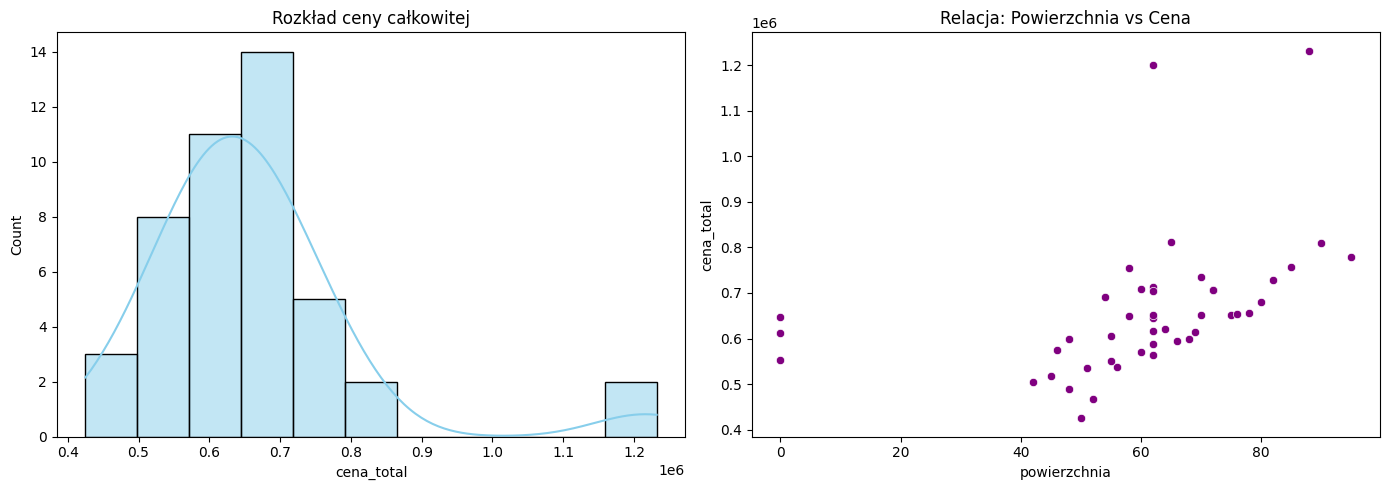

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.
braki_oznaczenia = ['NA', 'N/A', 'brak', 'brak danych', '?', '-', '']
df = pd.read_csv('nieruchomosci.csv', na_values=braki_oznaczenia)

# 2.
if df['powierzchnia'].dtype == 'object':
    df['powierzchnia'] = df['powierzchnia'].str.replace(',', '.').astype(float)

# 3.
for col in ['powierzchnia', 'rok_budowy', 'pietro']:
    df[col] = df[col].fillna(df[col].median())

for col in ['parking', 'balkon']:
    df[col] = df[col].fillna('nieznany')

# 4.
Q1 = df['cena_total'].quantile(0.25)
Q3 = df['cena_total'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['cena_total'] < (Q1 - 1.5 * IQR)) | (df['cena_total'] > (Q3 + 1.5 * IQR))]

print(f"Statystyki opisowe:\n{df.describe().to_string()}\n")
print(f"Liczba wykrytych outlierów cenowych (IQR): {len(outliers)}")

# 5.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['cena_total'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Rozkład ceny całkowitej')

sns.scatterplot(data=df, x='powierzchnia', y='cena_total', ax=axes[1], color='purple')
axes[1].set_title('Relacja: Powierzchnia vs Cena')

plt.tight_layout()
plt.show()